In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Load data
df = pd.read_csv('../data/processed/telecom_churn_processed.csv')
df.fillna(df.median(numeric_only=True), inplace=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Retrain same XGBoost
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    gamma=0.1, random_state=42, eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train_bal, y_train_bal)

print("Model retrained ✓")
print(f"Test set size : {X_test.shape[0]} customers")

Model retrained ✓
Test set size : 1409 customers


In [2]:
# Build SHAP explainer on the model
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values computed ✓")
print(f"Shape : {shap_values.shape}")
print(f"\nEach row = one customer")
print(f"Each column = one feature's contribution to churn prediction")

SHAP values computed ✓
Shape : (1409, 25)

Each row = one customer
Each column = one feature's contribution to churn prediction


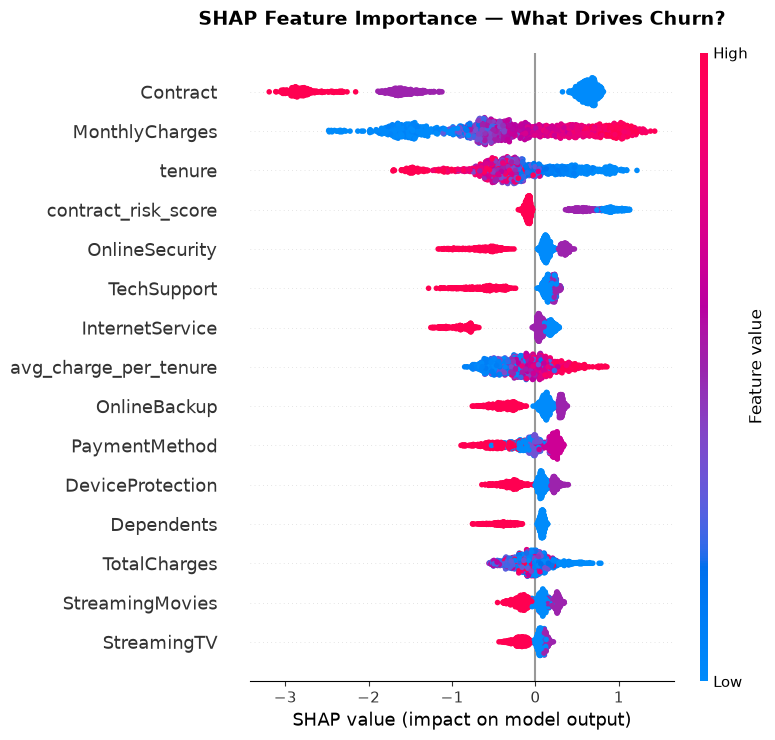

Chart saved ✓


In [3]:
# This is the most important chart in the whole project
# Shows WHICH features matter AND how they affect churn

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  show=False, max_display=15)
plt.title('SHAP Feature Importance — What Drives Churn?',
          fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../reports/13_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✓")

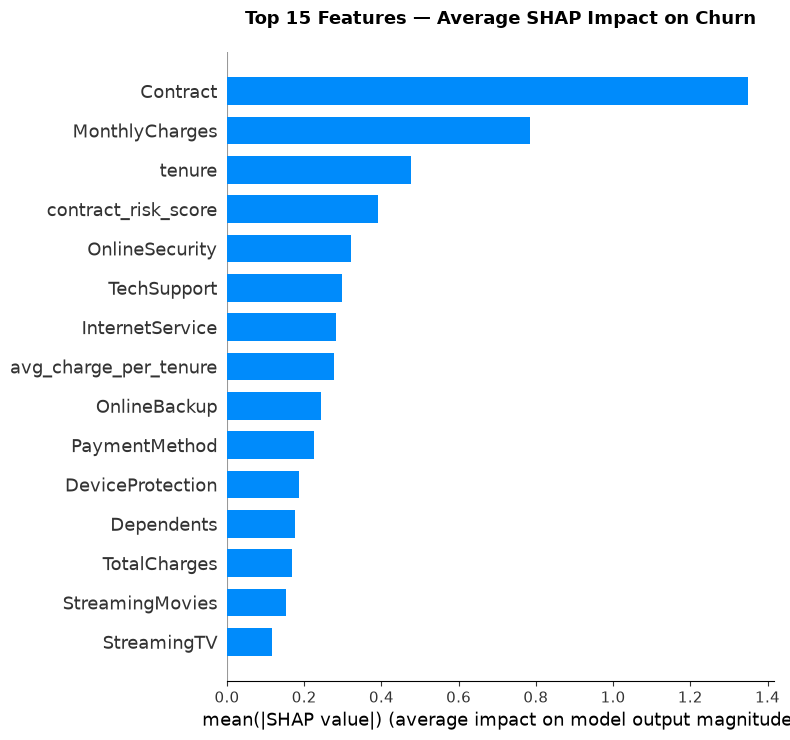

In [4]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=False, max_display=15)
plt.title('Top 15 Features — Average SHAP Impact on Churn',
          fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('../reports/14_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Explaining Customer at index: 1
Churn Probability : 83.20%
Risk Tier         : Critical
Actual Churn      : No


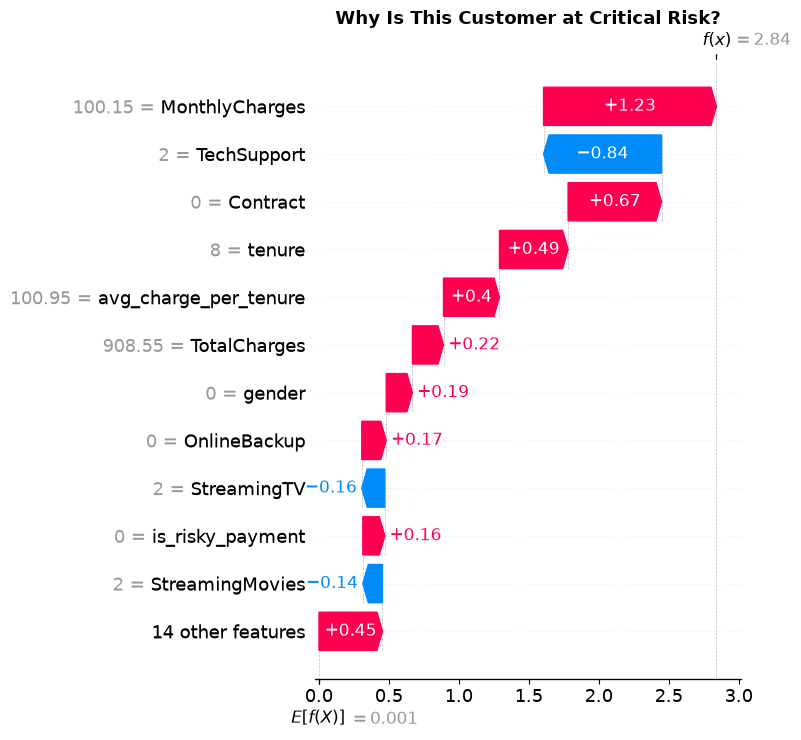

In [5]:
# Load predictions
pred_df = pd.read_csv('../data/predictions/churn_predictions.csv')

# Get index of a Critical risk customer
critical_idx = pred_df[pred_df['Risk_Tier'] == 'Critical'].index[0]

print(f"Explaining Customer at index: {critical_idx}")
print(f"Churn Probability : {pred_df.loc[critical_idx, 'Churn_Probability']:.2%}")
print(f"Risk Tier         : {pred_df.loc[critical_idx, 'Risk_Tier']}")
print(f"Actual Churn      : {'Yes' if pred_df.loc[critical_idx, 'Actual_Churn'] == 1 else 'No'}")

# SHAP waterfall for this customer
shap_display = shap.Explanation(
    values=shap_values[critical_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[critical_idx],
    feature_names=X.columns.tolist()
)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_display, max_display=12, show=False)
plt.title(f'Why Is This Customer at Critical Risk?',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/15_shap_waterfall_critical.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Convert SHAP values to a readable business report
shap_df = pd.DataFrame(shap_values, columns=X.columns)

# Mean absolute SHAP value per feature
feature_impact = shap_df.abs().mean().sort_values(ascending=False).head(10)

print("=" * 55)
print("   SHAP EXPLAINABILITY — BUSINESS TRANSLATION")
print("=" * 55)
print("\n  Top reasons customers are churning:\n")

business_labels = {
    'tenure'                  : 'Customer is relatively new',
    'contract_risk_score'     : 'On a month-to-month contract',
    'MonthlyCharges'          : 'Paying high monthly bills',
    'total_services'          : 'Using fewer company services',
    'is_risky_payment'        : 'Paying via electronic check',
    'avg_charge_per_tenure'   : 'High cost relative to tenure',
    'TotalCharges'            : 'Low total spend (newer customer)',
    'is_high_value'           : 'High value customer at risk',
    'InternetService'         : 'On Fiber Optic internet',
    'contract_risk_score'     : 'High contract risk profile',
}

for i, (feature, impact) in enumerate(feature_impact.items(), 1):
    label = business_labels.get(feature, feature)
    bar   = '█' * int(impact * 100)
    print(f"  {i:2}. {label}")
    print(f"      Impact: {bar} ({impact:.3f})\n")

print("=" * 55)
print("  All SHAP charts saved to /reports/")
print("  Next → Power BI Dashboard")
print("=" * 55)

   SHAP EXPLAINABILITY — BUSINESS TRANSLATION

  Top reasons customers are churning:

   1. Contract
      Impact: ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ (1.350)

   2. Paying high monthly bills
      Impact: ██████████████████████████████████████████████████████████████████████████████ (0.784)

   3. Customer is relatively new
      Impact: ███████████████████████████████████████████████ (0.475)

   4. High contract risk profile
      Impact: ███████████████████████████████████████ (0.392)

   5. OnlineSecurity
      Impact: ████████████████████████████████ (0.322)

   6. TechSupport
      Impact: █████████████████████████████ (0.298)

   7. On Fiber Optic internet
      Impact: ████████████████████████████ (0.282)

   8. High cost relative to tenure
      Impact: ███████████████████████████ (0.277)

   9. OnlineBackup
      Impact: ████████████████████████ (0.243)

  10. PaymentMethod
   

In [7]:
# Save SHAP values so Power BI can use them
shap_export = pd.DataFrame(
    shap_values,
    columns=[f'shap_{col}' for col in X.columns]
)
shap_export['Churn_Probability'] = xgb.predict_proba(X_test)[:, 1]

shap_export.to_csv('../data/predictions/shap_values.csv', index=False)
print("SHAP values exported for Power BI ✓")
print(f"File : data/predictions/shap_values.csv")
print(f"Shape: {shap_export.shape}")

SHAP values exported for Power BI ✓
File : data/predictions/shap_values.csv
Shape: (1409, 26)
